# Prac W4 - Basic Parametric models and Statistical Learning

### Aims:

- To gain some experience in performing regression with linear and polynomial models and 
classification with parametric models
- To produce some assessable work for this subject

(**Q1a**) Plot the function $f(x) = x^3 + 1$ over the domain $[-1,1]$. This is the "true" function
for our regression problem.

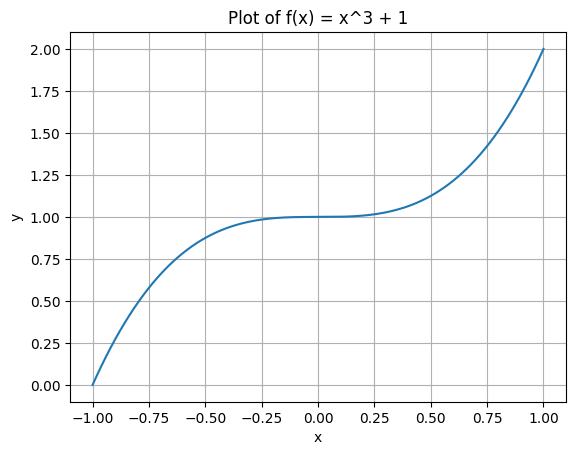

In [30]:
import numpy as np
import matplotlib.pyplot as plt

def f(x: float) -> float:
    return np.pow(x, 3) + 1

v_f = np.vectorize(f)

def plot_f() -> None:
    x_grid: np.array = np.arange(-1, 1.01, 0.01)
    y_grid: np.array = v_f(x_grid)

    plt.plot(x_grid, y_grid)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("Plot of f(x) = x^3 + 1")
    plt.grid()
    plt.show()

plot_f()

(**Q1b**) Create a "sample training set" of 30 points by generating a random set of x/input values
, and then corresponding outputs by evaluating the true function at each input value and adding
gaussian random noise. Plot the data on the same axes as the function

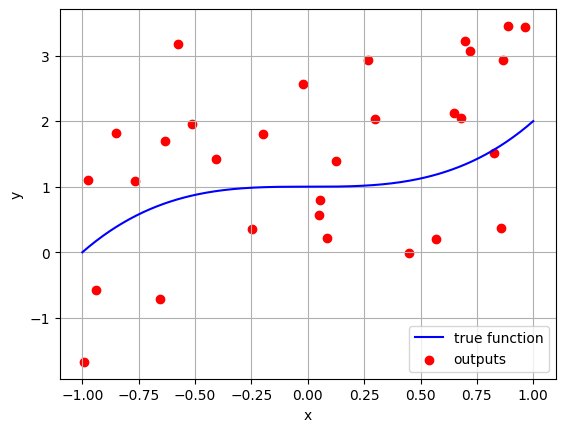

In [8]:
x_train: np.array = np.random.uniform(-1, 1, size=30)
y_train: np.array = v_f(x_train) + np.random.normal(size=30)

def plot_y_and_f(x: np.array, y: np.array) -> None:
    x_grid: np.array = np.arange(-1, 1.01, 0.01)
    y_grid: np.array = v_f(x_grid)

    plt.plot(x_grid, y_grid, label="true function", c="blue")
    plt.scatter(x_train, y_train, label="outputs", c="red")
    plt.legend()
    plt.xlabel("x")
    plt.ylabel("y")
    plt.grid()
    plt.show()

plot_y_and_f(x_train, y_train)

(**Q3c**) Perform linear regression using your training set and calculating the training set 
(sum of squares) error

In [27]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

def get_sum_of_squares(model: LinearRegression, x: np.ndarray, y: np.array) -> float:
    y_pred: np.array = model.predict(x)
    return mean_squared_error(y, y_pred) * y.shape[0]

def build_linreg_model(x: np.ndarray, y: np.array) -> LinearRegression:
    model = LinearRegression()
    model.fit(x,y)
    return model

x_train = x_train.reshape(-1, 1)
model: LinearRegression = build_linreg_model(x_train, y_train)
print(f"Linear Regression Sum of Squares {get_sum_of_squares(model, x_train, y_train)}")


Linear Regression Sum of Squares 40.16306292113653


(**Q3d**) Perform polynomial regression using your training set and calculate your training set
(sum of squares) error. Experiment with different order polynomials and observe the effect on 
the training set error

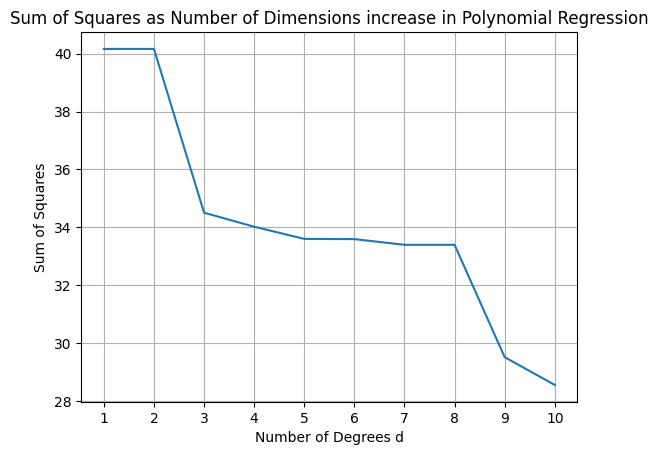

In [29]:
from sklearn.preprocessing import PolynomialFeatures

def build_polyreg_model(degree: int, x: np.ndarray, y: np.array) -> LinearRegression:
    x_poly = PolynomialFeatures(degree=degree, include_bias=False).fit_transform(x)
    return build_linreg_model(x_poly, y)

def plot_polyreg_models(max_degree: int, x: np.ndarray, y: np.array) -> None:
    degree_grid = np.arange(1, max_degree + 1)
    sum_of_squares_grid = []

    for d in degree_grid:
        model: LinearRegression = build_polyreg_model(d, x, y)
        x_poly = PolynomialFeatures(degree=d, include_bias=False).fit_transform(x)
        sum_of_squares_grid.append(get_sum_of_squares(model, x_poly, y))

    plt.plot(degree_grid, sum_of_squares_grid)
    plt.xlabel("Number of Degrees d")
    plt.ylabel("Sum of Squares")
    plt.title("Sum of Squares as Number of Dimensions increase in Polynomial Regression")
    plt.grid()
    plt.xticks(degree_grid)
    plt.show()

plot_polyreg_models(10, x_train, y_train)


(**Q2A**) Consider the dataset pokemonregr.csv. This contains 7 of the columns from the pokemon
pokemon dataset. Preview the first few lines to see what it looks like

In [37]:
import pandas as pd

def get_pokemon_df() -> pd.DataFrame:
    return pd.read_csv("./datasets/pokemonregr.csv", sep=",")

pokemon_df: pd.DataFrame = get_pokemon_df()
pokemon_df = pokemon_df.dropna()
print(pokemon_df)

     attack  defense  height_m  sp_attack  sp_defense  speed  weight_kg
0        30       35       0.3         20          20     45        2.9
1        20       55       0.7         25          25     30        9.9
2        45       50       1.1         90          80     70       32.0
3        35       30       0.3         20          20     50        3.2
4        25       50       0.6         25          25     35       10.0
..      ...      ...       ...        ...         ...    ...        ...
796      40       52       0.3         40          72     27        4.0
797      70       92       1.8         50         132     42       82.0
798      60      130       0.3         30         130      5        1.2
799     105       70       0.9         70          70     92       19.0
800      75      115       1.3         95         130     85       21.2

[781 rows x 7 columns]


(**Q2b**) Fit a linear regression model to the data, using the final column (weight
in kg as the output/target variable)

(**Q2c**) What are the coefficients/parameters of your regression model

In [40]:
pokemon_x = pokemon_df.iloc[:, :-1].to_numpy()
pokemon_y = pokemon_df.iloc[:, -1].to_numpy()

pokemon_model: LinearRegression = build_linreg_model(pokemon_x, pokemon_y)
print(f"Pokemon Data Headers: {pokemon_df.columns.to_list()}")
print(f"Pokemon Model Coefficients: {pokemon_model.coef_}")

Pokemon Data Headers: ['attack', 'defense', 'height_m', 'sp_attack', 'sp_defense', 'speed', 'weight_kg']
Pokemon Model Coefficients: [ 3.77397553e-01  5.67721520e-01  5.35146255e+01  2.45998765e-02
  1.53453033e-01 -4.21539817e-01]


(**Q2d**) Recall that the coefficients can be interpreted as a weight of importance of each weight 
to the predicted output. Which feature is most important for predicting weight?

Answer: defense and height_m, and speed are the most important features

(**Q2e**) One potential issue is that the data you have used is not normalised. Normalise your
input featurs and refit the linear regression model. Compare the coefficients for the resulting
model to your answer from (d)

In [42]:
from sklearn.preprocessing import StandardScaler

pokemon_x_scaled: np.ndarray = StandardScaler().fit_transform(pokemon_x)
pokemon_model_2: LinearRegression = build_linreg_model(pokemon_x_scaled, pokemon_y)
print(f"Pokemon Data Headers: {pokemon_df.columns.to_list()}")
print(f"Pokemon Model Coefficients: {pokemon_model_2.coef_}")

Pokemon Data Headers: ['attack', 'defense', 'height_m', 'sp_attack', 'sp_defense', 'speed', 'weight_kg']
Pokemon Model Coefficients: [ 12.15337036  17.47803453  57.77623107   0.79121435   4.29529442
 -12.17646811]


After scaling the data, it can be see that height_m is now the most important feature

(**Q3a**) Fit a logistic regression model to the data in w3classif.csv. What are the model parameter
values?

In [ ]:
from typing import Tuple
from sklearn.linear_model import LogisticRegression

def get_w3classif_data() -> Tuple[np.ndarray, np.array]:
    df: pd.DataFrame = pd.read_csv("./datasets/w3classif.csv", sep=",", header=None)
    return df.iloc[:, :-1].to_numpy(), df.iloc[: ,-1].to_numpy()

w3classif_x, w3classif_y = get_w3classif_data()
logreg = LogisticRegression(max_iter=1000).fit(w3classif_x, w3classif_y)
print(f"Logistic Regression Model Coefficients: {logreg.coef_}")

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
Logistic Regression Model Coefficients: [[1.76160217 1.76094615]]


(**Q3b**) Given a test data point $x` = (1.1, 1.1$), what does your model predict as $\mathbb{P}
(y' = 1 | x')$?

In [51]:
x_prime = np.array([1.1, 1.1]).reshape(1, -1)
logreg.predict_proba(x_prime)

array([[0.68957275, 0.31042725]])

The probability for class 1 for $x'$ is $\approx 31.04%$

(**Q3c**) Plot the data with discriminant function and the decision regions for your model

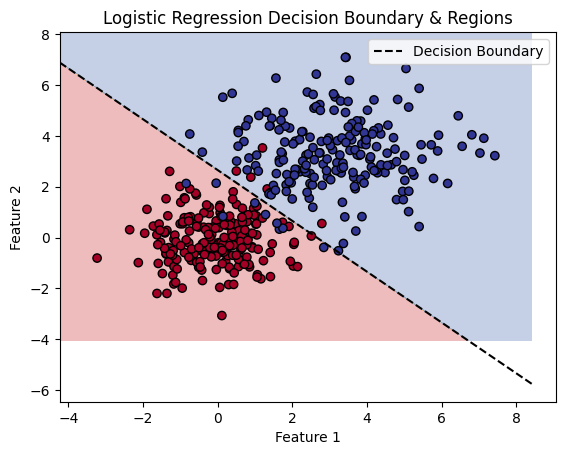

In [53]:
def plot_decision_regions(X, y, model):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdYlBu)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.RdYlBu)

    b0 = model.intercept_[0]
    b1, b2 = model.coef_[0]
    
    x1_values = np.array([x_min, x_max])
    x2_values = -(b1 * x1_values + b0) / b2
    
    plt.plot(x1_values, x2_values, 'k--', label="Decision Boundary")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title("Logistic Regression Decision Boundary & Regions")
    plt.legend()
    plt.show()

plot_decision_regions(w3classif_x, w3classif_y, logreg)